In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
sns.set_theme(palette="colorblind")

# Load data

Description of variables: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/bike_sharing_dataset_clean.csv", 
                 parse_dates=["date_time"], index_col="date_time")
df = df.asfreq('h')
df = df.drop(columns=["atemp"])
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17544 entries, 2011-01-01 00:00:00 to 2012-12-31 23:00:00
Freq: h
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   holiday     17544 non-null  float64
 1   workingday  17544 non-null  float64
 2   weather     17544 non-null  object 
 3   temp        17544 non-null  float64
 4   hum         17544 non-null  float64
 5   windspeed   17544 non-null  float64
 6   users       17544 non-null  float64
 7   month       17544 non-null  int64  
 8   hour        17544 non-null  int64  
 9   weekday     17544 non-null  int64  
dtypes: float64(6), int64(3), object(1)
memory usage: 1.5+ MB


In [4]:
df.head()

,holiday,workingday,weather,temp,hum,windspeed,users,month,hour,weekday
date_time,,,,,,,,,,
2011-01-01 00:00:00,0.0,0.0,clear,9.84,81.0,0.0,16.0,1,0,5
2011-01-01 01:00:00,0.0,0.0,clear,9.02,80.0,0.0,40.0,1,1,5
2011-01-01 02:00:00,0.0,0.0,clear,9.02,80.0,0.0,32.0,1,2,5
2011-01-01 03:00:00,0.0,0.0,clear,9.84,75.0,0.0,13.0,1,3,5
2011-01-01 04:00:00,0.0,0.0,clear,9.84,75.0,0.0,1.0,1,4,5


# Train-test split

In [5]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=7, shuffle=False)

In [6]:
train_set.shape, test_set.shape

((14035, 10), (3509, 10))

# EDA

<Axes: xlabel='date_time'>

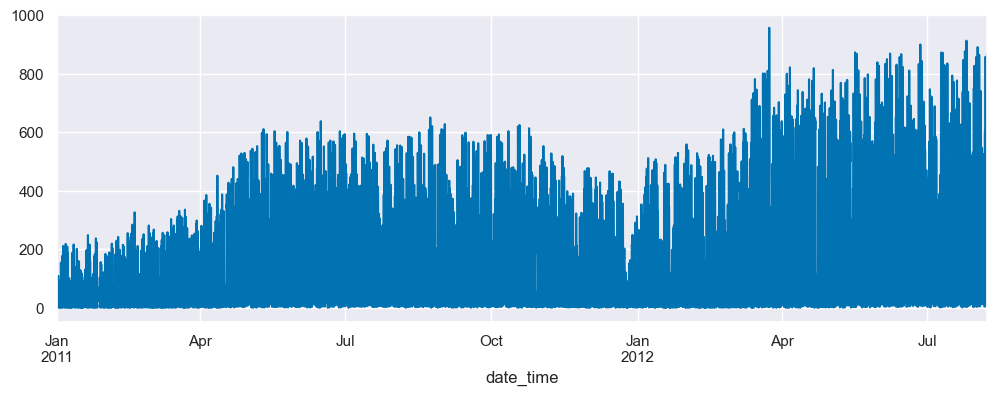

In [7]:
train_set["users"].plot(figsize=(12, 4))

# Preprocessing

## Encode trend

In [8]:
train_set["trend"] = np.arange(len(train_set))
test_set["trend"] = np.arange(len(train_set), len(train_set) + len(test_set))
train_set.head()

,holiday,workingday,weather,temp,hum,windspeed,users,month,hour,weekday,trend
date_time,,,,,,,,,,,
2011-01-01 00:00:00,0.0,0.0,clear,9.84,81.0,0.0,16.0,1,0,5,0
2011-01-01 01:00:00,0.0,0.0,clear,9.02,80.0,0.0,40.0,1,1,5,1
2011-01-01 02:00:00,0.0,0.0,clear,9.02,80.0,0.0,32.0,1,2,5,2
2011-01-01 03:00:00,0.0,0.0,clear,9.84,75.0,0.0,13.0,1,3,5,3
2011-01-01 04:00:00,0.0,0.0,clear,9.84,75.0,0.0,1.0,1,4,5,4


## One-hot encoding

In [38]:
df["weather"].unique()

array(['clear', 'mist', 'rain'], dtype=object)

In [9]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["weather"]

encoder = OneHotEncoder(drop='first')
encoded = encoder.fit_transform(train_set[categorical_features])
encoded_df = pd.DataFrame(encoded.toarray(), 
                          columns=encoder.get_feature_names_out(categorical_features), 
                          index=train_set.index)
encoded_df.head()

,weather_mist,weather_rain
date_time,,
2011-01-01 00:00:00,0.0,0.0
2011-01-01 01:00:00,0.0,0.0
2011-01-01 02:00:00,0.0,0.0
2011-01-01 03:00:00,0.0,0.0
2011-01-01 04:00:00,0.0,0.0


In [10]:
# add the one-hot features to the train set
train_set = pd.concat([train_set, encoded_df], axis=1)

In [11]:
# transform the test set as well
encoded_test = encoder.transform(test_set[categorical_features])
encoded_test_df = pd.DataFrame(encoded_test.toarray(), 
                               columns=encoder.get_feature_names_out(categorical_features), 
                               index=test_set.index)
encoded_test_df.head()

,weather_mist,weather_rain
date_time,,
2012-08-07 19:00:00,1.0,0.0
2012-08-07 20:00:00,1.0,0.0
2012-08-07 21:00:00,1.0,0.0
2012-08-07 22:00:00,0.0,0.0
2012-08-07 23:00:00,0.0,0.0


In [12]:
# add the one-hot features to the test set
test_set = pd.concat([test_set, encoded_test_df], axis=1)

In [13]:
# drop the categorical columns since they're now encoded
train_set.drop(columns=categorical_features, inplace=True)
test_set.drop(columns=categorical_features, inplace=True)

## Cyclical features

In [40]:
# hour
train_set["hour_sin"] = np.sin(2 * np.pi * train_set.index.hour / 24)
train_set["hour_cos"] = np.cos(2 * np.pi * train_set.index.hour / 24)

test_set["hour_sin"] = np.sin(2 * np.pi * test_set.index.hour / 24)
test_set["hour_cos"] = np.cos(2 * np.pi * test_set.index.hour / 24)

# weekday
train_set["weekday_sin"] = np.sin(2 * np.pi * train_set.index.dayofweek / 7)
train_set["weekday_cos"] = np.cos(2 * np.pi * train_set.index.dayofweek / 7)

test_set["weekday_sin"] = np.sin(2 * np.pi * test_set.index.dayofweek / 7)
test_set["weekday_cos"] = np.cos(2 * np.pi * test_set.index.dayofweek / 7)

# month
train_set["month_sin"] = np.sin(2 * np.pi * train_set.index.month / 12)
train_set["month_cos"] = np.cos(2 * np.pi * train_set.index.month / 12)

test_set["month_sin"] = np.sin(2 * np.pi * test_set.index.month / 12)
test_set["month_cos"] = np.cos(2 * np.pi * test_set.index.month / 12)

In [41]:
train_set.head()

,holiday,workingday,temp,hum,windspeed,users,trend,weather_mist,weather_rain,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos
date_time,,,,,,,,,,,,,,,
2011-01-01 00:00:00,0.0,0.0,9.84,81.0,0.0,16.0,0,0.0,0.0,0.000000,1.000000,-0.974928,-0.222521,0.5,0.866025
2011-01-01 01:00:00,0.0,0.0,9.02,80.0,0.0,40.0,1,0.0,0.0,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025
2011-01-01 02:00:00,0.0,0.0,9.02,80.0,0.0,32.0,2,0.0,0.0,0.500000,0.866025,-0.974928,-0.222521,0.5,0.866025
2011-01-01 03:00:00,0.0,0.0,9.84,75.0,0.0,13.0,3,0.0,0.0,0.707107,0.707107,-0.974928,-0.222521,0.5,0.866025
2011-01-01 04:00:00,0.0,0.0,9.84,75.0,0.0,1.0,4,0.0,0.0,0.866025,0.500000,-0.974928,-0.222521,0.5,0.866025


In [ ]:
# drop the cyclical columns since they're now encoded
train_set.drop(columns=["hour", "weekday", "month"], inplace=True)
test_set.drop(columns=["hour", "weekday", "month"], inplace=True)

## Put the full set back together for modelling

In [20]:
full_set = pd.concat([train_set, test_set])

# Model development

## Set up TimeSeriesFold

In [21]:
from skforecast.model_selection import TimeSeriesFold
from sklearn.metrics import root_mean_squared_error


cv = TimeSeriesFold(
         steps=24, # =forecast horizon
         initial_train_size=train_set.shape[0], # size of the initial training set
         refit=False, # if true, the forecaster is refitted at each fold
         fixed_train_size=False # fixed-size or expanding training data
     )

## Baseline

In [22]:
from skforecast.recursive import ForecasterEquivalentDate
from skforecast.model_selection._validation import backtesting_forecaster


last_value_forecaster = ForecasterEquivalentDate(offset=1, n_offsets=1)

results_lv, predictions_backtest = backtesting_forecaster(
                                   forecaster=last_value_forecaster,
                                   y=df['users'],
                                   cv=cv,
                                   metric=[root_mean_squared_error, 
                                           'mean_absolute_error'],
                                   n_jobs='auto',
                                   verbose=False,
                                   show_progress=True
                               )
results_lv.index = ["Last-Value"]

  0%|          | 0/147 [00:00<?, ?it/s]

In [23]:
results_lv

,root_mean_squared_error,mean_absolute_error
Last-Value,412.611249,336.979196


## Random Forest

### Hyperparameter optimisation

In [24]:
from sklearn.ensemble import RandomForestRegressor
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import grid_search_forecaster

import warnings
from skforecast.exceptions import IgnoredArgumentWarning
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)


forecaster = ForecasterRecursive(
    estimator=RandomForestRegressor(),
    lags=24
)

# Lags grid
lags_grid = [6, 12, 24]

# Hyperparameter search space
hp_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
}

# list of exog features
exog_features = train_set.columns.to_list()
exog_features.remove("users")

cv_hp_search = TimeSeriesFold(
    steps=24, # =forecast horizon
    initial_train_size=int(len(train_set) * 0.8), # 80% training, 20% validation
    refit=False, # if true, the forecaster is refitted at each fold
    fixed_train_size=False # fixed-size or expanding training data
)

results_search = grid_search_forecaster(
    forecaster=forecaster,
    y=train_set["users"],
    exog=train_set[exog_features],  
    cv=cv_hp_search,
    param_grid=hp_grid,
    lags_grid=lags_grid,
    metric='mean_absolute_error',
    return_best=True
)

lags grid:   0%|          | 0/3 [00:00<?, ?it/s]

params grid:   0%|          | 0/24 [00:00<?, ?it/s]

params grid:   0%|          | 0/24 [00:00<?, ?it/s]

params grid:   0%|          | 0/24 [00:00<?, ?it/s]

In [25]:
results_search.head(3)

,lags,lags_label,params,mean_absolute_error,max_depth,min_samples_split,n_estimators
0,"[1, 2, 3, 4, 5, 6]","[1, 2, 3, 4, 5, 6]","{'max_depth': None, 'min_samples_split': 5, 'n...",48.716117,NaN,5.0,200.0
1,"[1, 2, 3, 4, 5, 6]","[1, 2, 3, 4, 5, 6]","{'max_depth': None, 'min_samples_split': 5, 'n...",48.972281,NaN,5.0,100.0
2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","{'max_depth': None, 'min_samples_split': 2, 'n...",49.019708,NaN,2.0,100.0


In [26]:
best_params = results_search['params'].iat[0]
best_params

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

In [27]:
best_lags = results_search['lags'].iat[0]
best_lags

array([1, 2, 3, 4, 5, 6])

### Evaluate the best model on test set

In [28]:
results_rf, predictions = backtesting_forecaster(
                        forecaster=forecaster, # use the forecaster with the best HPs found in the search
                        y=full_set['users'],
                        exog=full_set[exog_features],
                        cv=cv,
                        metric=[root_mean_squared_error, 
                                 'mean_absolute_error'],
                     )
results_rf.index = ["Random Forest"]
results_rf

  0%|          | 0/147 [00:00<?, ?it/s]

,root_mean_squared_error,mean_absolute_error
Random Forest,95.684315,53.381832


### Plot predictions

<Axes: >

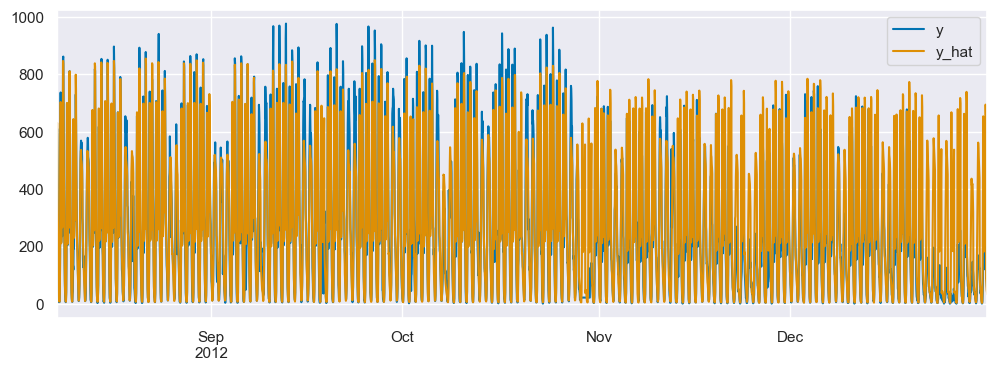

In [29]:
tdf = pd.DataFrame({"y": test_set['users'], "y_hat": predictions['pred']})
tdf.plot(figsize=(12,4))

<Axes: >

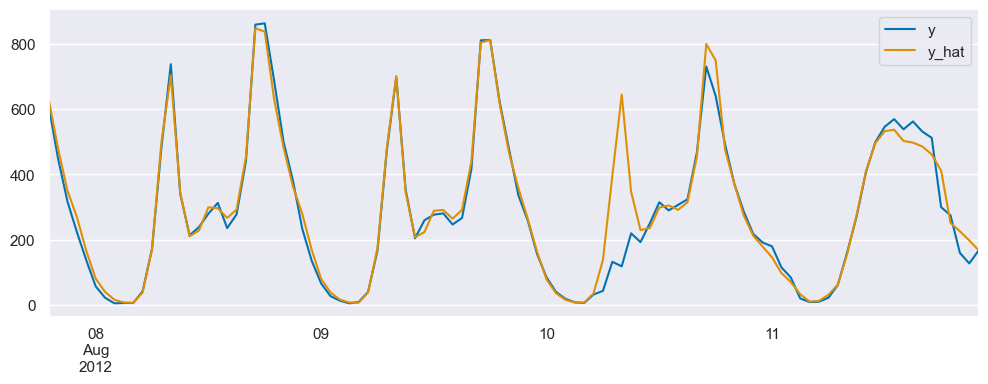

In [30]:
# the first 100 predictions
tdf.iloc[:100, :].plot(figsize=(12,4))

### Feature Selection

In [31]:
from skforecast.feature_selection import select_features
from sklearn.feature_selection import RFECV

rf = RandomForestRegressor(**best_params)
selector = RFECV(estimator=rf, step=1, cv=5, scoring='neg_mean_absolute_error')

selected_lags, selected_window_features, selected_exog = select_features(
    forecaster=forecaster,
    selector=selector, # or, SelectKBest(f_regression, k=5)
    y=train_set['users'],  
    exog=train_set[exog_features],
    subsample=1.0, 
    random_state=7,
    verbose=True
)

Recursive feature elimination (RFECV)
-------------------------------------
Total number of records available: 14029
Total number of records used for feature selection: 14029
Number of features available: 20
    Lags            (n=6)
    Window features (n=0)
    Exog            (n=14)
Number of features selected: 17
    Lags            (n=6) : [1, 2, 3, 4, 5, 6]
    Window features (n=0) : []
    Exog            (n=11) : ['workingday', 'temp', 'hum', 'windspeed', 'trend', 'weather_rain', 'hour_sin', 'hour_cos', 'weekday_sin', 'month_sin', 'month_cos']


### Re-run backtesting on selected features

In [32]:
forecaster = ForecasterRecursive(
    estimator=RandomForestRegressor(**best_params),
    lags=selected_lags
)

results_rf_fs, predictions = backtesting_forecaster(
                        forecaster=forecaster, 
                        y=full_set['users'],
                        exog=full_set[selected_exog],
                        cv=cv,
                        metric=[root_mean_squared_error, 
                                 'mean_absolute_error'],
                        n_jobs=1,
                     )
results_rf_fs.index = ["Random Forest (feature selection)"]
results_rf_fs

  0%|          | 0/147 [00:00<?, ?it/s]

,root_mean_squared_error,mean_absolute_error
Random Forest (feature selection),94.446995,52.347718


# Summary table

In [33]:
tdf = pd.concat([results_lv, results_rf, results_rf_fs], axis=0)
tdf

,root_mean_squared_error,mean_absolute_error
Last-Value,412.611249,336.979196
Random Forest,95.684315,53.381832
Random Forest (feature selection),94.446995,52.347718


## Feature importances

### Model-specific scores

In [34]:
forecaster.fit(y=train_set['users'], exog=train_set[exog_features])
importances = forecaster.get_feature_importances()
importances

,feature,importance
0,lag_1,0.737635
14,hour_sin,0.107413
15,hour_cos,0.046602
11,trend,0.025122
7,workingday,0.022368
5,lag_6,0.018138
1,lag_2,0.008383
3,lag_4,0.007519
2,lag_3,0.005122
8,temp,0.005122


### SHAP

In [35]:
import shap

X_train, y_train = forecaster.create_train_X_y(
    y=train_set['users'], exog=train_set[exog_features])

explainer = shap.TreeExplainer(forecaster.estimator)

shap_values = explainer.shap_values(X_train)

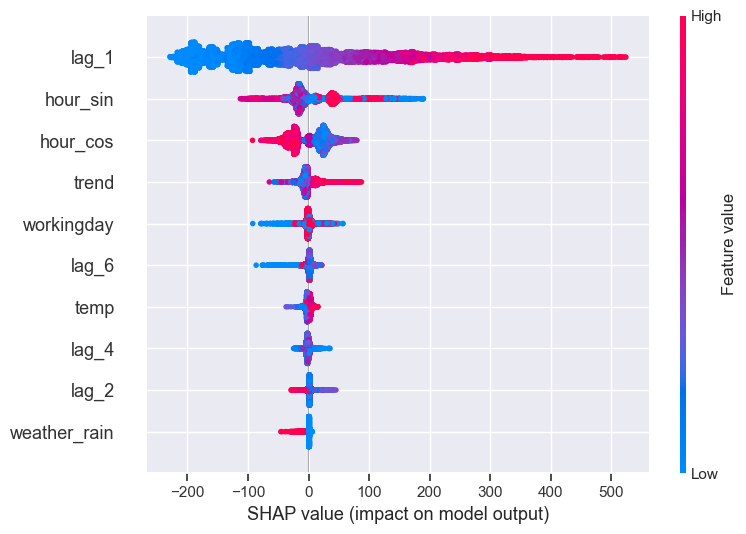

In [36]:
shap.initjs()
shap.summary_plot(shap_values, X_train, max_display=10, show=False)